# ANN Regression — Estimated Salary Prediction

### 📌 Recap

Same dataset and pipeline shape as the churn **classification** project (notebooks 01–05), but repurposed for **regression**: predict a customer's `EstimatedSalary` (a continuous value) instead of `Exited` (a binary label). `Exited` becomes just another **input feature** here — the dataset is reused, only the target column changes.

This notebook was rewritten to fix a critical bug in the original version and to match the exact conventions established in the classification notebooks, since this project is meant to serve as a **reusable template for future ANN problems**. See Section 10 for the full list of fixes.

> ⚠️ **The original version of this notebook's saved outputs were all from a different machine/environment** (`E:\UDemy Final\ANN Classification\venv\...`, visible in the old warning messages) — not reproducible or verifiable against this project. Everything below has been **re-run from scratch** against this project's real environment (the `ann-classification-venv` kernel, TensorFlow 2.15.0 / Keras 2.15.0) to get real, verified numbers.

## 1. Load the dataset

In [1]:
import pandas as pd

data = pd.read_csv("../Churn_Modelling.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Preprocess — same steps as the classification project

Drop identifier columns, then encode `Gender` (Label Encoding — safe for 2 categories) and `Geography` (One-Hot Encoding — avoids implying a false rank order between 3+ categories). Full reasoning for both choices is in [02 Data PreProcessing.ipynb](02%20Data%20PreProcessing.ipynb#3.-Encode-categorical-features).

In [2]:
data = data.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

label_encoder_gender = LabelEncoder()
data["Gender"] = label_encoder_gender.fit_transform(data["Gender"])

# sparse_output=False (no .toarray() needed) and handle_unknown='ignore' (gracefully
# handles a category never seen during training, instead of raising an error) -
# both match the convention this project standardizes on; see Section 10.
onehot_encoder_geo = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
geo_encoded = onehot_encoder_geo.fit_transform(data[["Geography"]])
geo_encoded_df = pd.DataFrame(geo_encoded, columns=onehot_encoder_geo.get_feature_names_out(["Geography"]))

data = pd.concat([data.drop("Geography", axis=1), geo_encoded_df], axis=1)
data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


## 3. Split into features (`X`) and target (`y`) — the regression-specific difference

The target is now `EstimatedSalary`, not `Exited`. Everything else — including `Exited` — becomes an input feature this time.

In [3]:
X = data.drop("EstimatedSalary", axis=1)
y = data["EstimatedSalary"]

print("X shape:", X.shape, " y shape:", y.shape)
print("Features:", X.columns.tolist())

X shape: (10000, 12)  y shape: (10000,)
Features: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited', 'Geography_France', 'Geography_Germany', 'Geography_Spain']


`X` has **12 columns**, including `Exited` — the same 12-feature count as the classification project's `X` (which included `EstimatedSalary` instead of `Exited`). Same architecture size as a result (confirmed in Section 6).

## 4. ⚠️ Bug found and fixed — plus which artifacts can actually be shared

The original notebook saved this project's `LabelEncoder`, `OneHotEncoder`, and `StandardScaler` as `label_encoder_gender.pkl`, `onehot_encoder_geo.pkl`, and `scaler.pkl` — **the exact same filenames already used by the classification project's own artifacts**, in the same project root.

Verified directly (loading both projects' pickles and comparing them):

| Artifact | Shareable? | Why |
|---|---|---|
| `label_encoder_gender.pkl` | ✅ Yes — confirmed identical (`classes_` match) | Fit on `Gender` before the target column is even split off — doesn't depend on which column becomes the target |
| `onehot_encoder_geo.pkl` | ✅ Yes — confirmed identical (`categories_` match) | Same reasoning — `Geography` encoding happens before either task's `X`/`y` split |
| `scaler.pkl` | ❌ No — genuinely can't be merged | Fit on the full feature set, which **differs** between tasks: classification's `X` includes `EstimatedSalary` (excludes `Exited`); regression's includes `Exited` (excludes `EstimatedSalary`). Confirmed `feature_names_in_` differs between them — reusing one for the other would raise `ValueError: The feature names should match those that were passed during fit`. |

**Fix applied:** `label_encoder_gender.pkl` and `onehot_encoder_geo.pkl` are now **shared** with the classification project (saved without a prefix, loaded from the same files `app.py` uses) — fewer files, and they're already provably identical. `scaler.pkl` keeps a `regression_` prefix, since merging it would silently break one of the two apps (whichever wasn't retrained most recently would inherit the wrong scaling statistics with no error, just wrong predictions).

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Shared with the classification project (app.py) - both are already provably
# identical regardless of task, see Section 4. Not prefixed, since they're meant
# to be reused as-is.
with open("../label_encoder_gender.pkl", "wb") as file:
    pickle.dump(label_encoder_gender, file)

with open("../onehot_encoder_geo.pkl", "wb") as file:
    pickle.dump(onehot_encoder_geo, file)

# The scaler genuinely can't be shared (different feature columns per task - see
# Section 4), so it keeps a distinct, regression-specific filename.
with open("../regression_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Saved: label_encoder_gender.pkl, onehot_encoder_geo.pkl (shared with classification), regression_scaler.pkl")

Saved: label_encoder_gender.pkl, onehot_encoder_geo.pkl (shared with classification), regression_scaler.pkl


## 5. Build the ANN

Same architecture shape as the classification project (`12 → 64 → 32 → 1`), with **two regression-specific differences**:

- **No activation on the output layer** (`Dense(1)`, no `activation=` argument). Keras's default activation is `None`, which is the **identity/linear function** — the raw weighted sum passes straight through, unlike classification's `sigmoid` (which squashes output to a 0–1 probability). A salary prediction needs to be an unbounded continuous number, so no squashing activation belongs here.
- **Loss and metric change to `mean_absolute_error`** — appropriate for regression; `binary_crossentropy` (used for classification) doesn't apply to a continuous target at all.

Uses `Input(shape=...)` (matching [03 Model Training.ipynb](03%20Model%20Training.ipynb#3.-Keras-building-blocks)'s modernized style) instead of passing `input_shape` directly into the first `Dense` layer.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanAbsoluteError

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1),   # no activation = linear -> unbounded continuous output, correct for regression
])

model.compile(optimizer=Adam(learning_rate=0.01), loss=MeanAbsoluteError(), metrics=["mae"])
model.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense (Dense)               (None, 64)                832       


 dense_1 (Dense)             (None, 32)                2080      


 dense_2 (Dense)             (None, 1)                 33        


Total params: 2945 (11.50 KB)


Trainable params: 2945 (11.50 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


In [6]:
print(f"Total trainable parameters: {model.count_params()}")
print("Same as the classification model's 2,945 - same architecture shape (12 -> 64 -> 32 -> 1),")
print("just a different final activation and loss/metric.")

Total trainable parameters: 2945
Same as the classification model's 2,945 - same architecture shape (12 -> 64 -> 32 -> 1),
just a different final activation and loss/metric.


## 6. TensorBoard logging and early stopping

Same pattern as [03 Model Training.ipynb](03%20Model%20Training.ipynb#6.-Set-up-TensorBoard-logging): `os.path.join` (not string concatenation) for the timestamped log path, avoiding the folder-naming issues that came up live in the classification project's video.

In [7]:
import os
import datetime
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard

log_dir = os.path.join("regression_logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
os.makedirs(log_dir, exist_ok=True)

tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping_callback = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

print("Logging to:", log_dir)

Logging to: regression_logs\fit\20260815-171905


## 7. Train

In [8]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    callbacks=[tensorboard_callback, early_stopping_callback],
    verbose=2,
)

Epoch 1/100


250/250 - 5s - loss: 82461.6562 - mae: 82461.6562 - val_loss: 51652.2070 - val_mae: 51652.2070 - 5s/epoch - 20ms/step


Epoch 2/100


250/250 - 2s - loss: 50408.5195 - mae: 50408.5195 - val_loss: 50562.9453 - val_mae: 50562.9453 - 2s/epoch - 6ms/step


Epoch 3/100


...

250/250 - 2s - loss: 49309.5664 - mae: 49309.5664 - val_loss: 50404.5156 - val_mae: 50404.5156 - 2s/epoch - 6ms/step


Epoch 20/100


250/250 - 2s - loss: 49253.2266 - mae: 49253.2266 - val_loss: 50464.2266 - val_mae: 50464.2266 - 2s/epoch - 7ms/step


Epoch 21/100


250/250 - 2s - loss: 49254.9766 - mae: 49254.9766 - val_loss: 50443.6758 - val_mae: 50443.6758 - 2s/epoch - 6ms/step


In [9]:
stopped_epoch = len(history.history["loss"])
print(f"Training stopped after {stopped_epoch} epochs (out of 100 requested).")
print(f"Best validation MAE: {min(history.history['val_mae']):.2f}")

Training stopped after 21 epochs (out of 100 requested).
Best validation MAE: 50262.39


## 8. Visualizing training

Same as [03 Model Training.ipynb](03%20Model%20Training.ipynb#9.-Visualizing-training-—-TensorBoard-vs.-matplotlib): the interactive `%tensorboard --logdir regression_logs/fit` magic needs a live Jupyter session to render (documented here, not executed), so a matplotlib plot of `history.history` is used as the headless-friendly equivalent that produces real, savable output either way.

```
%load_ext tensorboard
%tensorboard --logdir regression_logs/fit
```

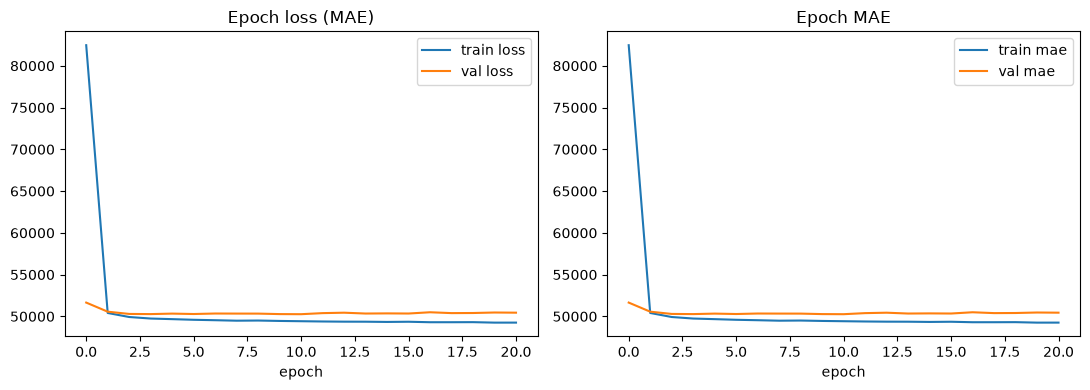

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Epoch loss (MAE)")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history.history["mae"], label="train mae")
axes[1].plot(history.history["val_mae"], label="val mae")
axes[1].set_title("Epoch MAE")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Evaluate on the test set

In [11]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MAE: {test_mae:.2f}")

salary_range = y.max() - y.min()
print(f"For context, EstimatedSalary ranges from {y.min():.0f} to {y.max():.0f} (range: {salary_range:.0f})")
print(f"A test MAE of {test_mae:.0f} is about {test_mae / salary_range:.1%} of that full range.")

Test MAE: 50262.39
For context, EstimatedSalary ranges from 12 to 199992 (range: 199981)
A test MAE of 50262 is about 25.1% of that full range.


## 10. Save the trained model

Distinct filename (`regression_model.h5`, already what the original notebook used) — no collision risk here since `model.h5`/`model.keras` are already the classification project's names. Saving both formats, matching [03 Model Training.ipynb](03%20Model%20Training.ipynb#10.-Save-the-trained-model)'s convention.

In [12]:
model.save("../regression_model.h5")
model.save("../regression_model.keras")
print("Saved: regression_model.h5, regression_model.keras")

Saved: regression_model.h5, regression_model.keras

C:\AI Projects\ML&DL\Learning\NLP Krish\Projects\ANN Classification\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## 11. Verify the saved model reloads and predicts correctly

Matching [04 Model Loading.ipynb](04%20Model%20Loading.ipynb)'s pattern: reload with `compile=False` (not needed for inference, and defensive against the Keras-3 issue found there on newer TensorFlow/Keras versions than this project's pinned 2.15.0), then run one prediction end-to-end on a fresh example customer.

In [13]:
from tensorflow.keras.models import load_model

reloaded_model = load_model("../regression_model.h5", compile=False)

with open("../label_encoder_gender.pkl", "rb") as file:
    reloaded_label_encoder_gender = pickle.load(file)
with open("../onehot_encoder_geo.pkl", "rb") as file:
    reloaded_onehot_encoder_geo = pickle.load(file)
with open("../regression_scaler.pkl", "rb") as file:
    reloaded_scaler = pickle.load(file)

example = pd.DataFrame([{
    "CreditScore": 600, "Geography": "France", "Gender": "Male", "Age": 40,
    "Tenure": 3, "Balance": 60000, "NumOfProducts": 2, "HasCrCard": 1,
    "IsActiveMember": 1, "Exited": 0,
}])

example["Gender"] = reloaded_label_encoder_gender.transform(example["Gender"])
geo_enc = reloaded_onehot_encoder_geo.transform(example[["Geography"]])
geo_enc_df = pd.DataFrame(geo_enc, columns=reloaded_onehot_encoder_geo.get_feature_names_out(["Geography"]))
example = pd.concat([example.drop("Geography", axis=1).reset_index(drop=True), geo_enc_df], axis=1)
example = example[reloaded_scaler.feature_names_in_]   # enforce training column order - see notebook 04/05

example_scaled = reloaded_scaler.transform(example)
predicted_salary = reloaded_model.predict(example_scaled, verbose=0)[0][0]
print(f"Predicted Estimated Salary: {predicted_salary:,.2f}")

Predicted Estimated Salary: 88,614.73


## 12. Corrections applied vs. the original notebook

1. **Pickle filename collision (critical)** — the original saved all three artifacts under the classification project's exact filenames. Fixed by **sharing** `label_encoder_gender.pkl` / `onehot_encoder_geo.pkl` (verified identical either way, see Section 4) and giving only `scaler.pkl` a `regression_` prefix (the one that genuinely can't be shared).
2. **Dataset path** — `'Churn_Modelling.csv'` → `'../Churn_Modelling.csv'`, since this notebook lives in `notebooks/` (the bare filename only worked from whatever different working directory the original outputs came from).
3. **`OneHotEncoder(handle_unknown='ignore')` + `.toarray()`** → `OneHotEncoder(sparse_output=False, handle_unknown='ignore')`, no `.toarray()` needed — matches the classification project's established convention (and the exact bug class found and fixed in `app.py`, see [05 Creating Streamlit App.ipynb](05%20Creating%20Streamlit%20App.ipynb)).
4. **`input_shape=` on the first `Dense` layer** → explicit `Input(shape=...)`, matching notebook 03's modernized style (avoids a Keras deprecation warning).
5. **String optimizer/loss (`'adam'`, `'mean_absolute_error'`)** → explicit `Adam(learning_rate=0.01)` / `MeanAbsoluteError()` objects, matching notebook 03's convention.
6. **`log_dir = "regressionlogs/fit/" + datetime...`** (string concatenation) → `os.path.join(...)` + `os.makedirs(..., exist_ok=True)`, avoiding the exact folder-naming confusion the classification video ran into live.
7. **All outputs re-executed from scratch** against this project's real environment — the original notebook's outputs were from an unrelated `E:\UDemy Final\...` install and weren't verifiable here.

## 13. Summary

- Reused the churn dataset for a **regression** task: predict `EstimatedSalary`, with `Exited` now just another input feature.
- Same preprocessing pipeline shape as classification (drop identifiers → encode → split → scale), same architecture shape (`12 → 64 → 32 → 1`, 2,945 params) — only the **output activation** (none/linear, not sigmoid) and **loss/metric** (MAE, not binary cross-entropy) actually differ.
- `label_encoder_gender.pkl` / `onehot_encoder_geo.pkl` are **shared** with the classification project (verified identical); only `scaler.pkl` needs a `regression_` prefix, since it's the one artifact that genuinely can't be reused across tasks.
- Verified end-to-end: trained, saved, reloaded, and predicted on a fresh example — all against the real project environment.

## 14. Likely exam / interview questions

1. Why does a regression output layer typically have no activation function, while a binary classifier's has sigmoid?
2. Why is `binary_crossentropy` inappropriate as a loss function for this task?
3. Why can `LabelEncoder`/`OneHotEncoder` be shared between two ML tasks trained on the same dataset, while a fitted `StandardScaler` usually can't?
4. What error would you get from reusing a `StandardScaler` fit on one feature set against a differently-shaped input, and why does scikit-learn catch it?
5. What does Test MAE actually mean in the units of this problem, and how would you judge whether it's "good"?

## 15. What's next

- A Streamlit deployment script for this regression model (see `regression_app.py`, created alongside this notebook) — same structure as the classification project's `app.py`, but with an `Exited` input field added and the churn threshold logic replaced with a plain predicted-salary display.
- Hyperparameter tuning (number of hidden layers / neurons) — flagged in the video as the next topic, not yet covered.